# Эксперимент B: качество трафик-менеджера

Вопрос: сколько KPI даёт лайв-исполнение по сравнению с замороженным исполнением того же утверждённого плана, и как быстро оно реагирует на шок. План фиксирован, единственное различие внутри пары — режим исполнения.

- **Режимы.** `frozen` — план исполняется как утверждён. `adaptive` — каждый час перепланирование, но с удержанием утверждённого микса, если прогноз укладывается в план. `adaptive_max` — каждый час максимизация оставшегося KPI на калиброванной модели.
- **Шоки** на канале с наибольшим бюджетом плана с середины кампании (час 252): CTR ×0,6, CPM ×1,6, спрос ×0,5, пауза 72 ч.
- **Метрики пары** (лайв против frozen на том же мире, сиде, истории и шоке): прирост KPI; доля возвращённых потерь `(live − frozen_shock) / (frozen_calm − frozen_shock)`; реакция — часы после шока до момента, когда лайв-план срезал кэп пострадавшего канала на 20 % относительно того же режима без шока (сглаживание 6 ч); доля перераспределённого бюджета; освоение бюджета; отклонение факта от утверждённого плана (метрика кейса).
- Миры 1–8, кампанийные сиды 1–2, конверсии, 1,2 млн, 21 день; история 3 кампании (тёплый план) и 0 (холодный).

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS = Path('.').resolve() / 'tm'
if not (RESULTS / 'pairs.json').exists():
    RESULTS = Path('media_planner/tools/evaluation/results/tm')
FIG = RESULTS.parent / 'figures'; FIG.mkdir(exist_ok=True)
pairs = pd.DataFrame(json.load(open(RESULTS / 'pairs.json')))
runs = pd.DataFrame(json.load(open(RESULTS / 'all_runs.json')))
pairs['abs_dev'] = pairs.dev_kpi.abs()
SCEN = ['none', 'ctr_drop', 'cpm_spike', 'supply_drop', 'pause']
SCEN_RU = {'none': 'без шока', 'ctr_drop': 'CTR ×0,6', 'cpm_spike': 'CPM ×1,6', 'supply_drop': 'спрос ×0,5', 'pause': 'пауза 72 ч'}
def table(df, by):
    g = df.groupby(by)
    out = pd.DataFrame({
        'пар': g.size(),
        'прирост p50': g.uplift.median(),
        'прирост p10': g.uplift.quantile(0.1),
        'побед': g.uplift.apply(lambda s: (s > 0).mean()),
        'возвращено p50': g.recovered.median(),
        'реакция, ч p50': g.reaction_hours.median(),
        'отреагировал': g.reaction_hours.apply(lambda s: s.notna().mean()),
        'перераспределено p50': g.reallocated.median(),
        'освоение p50': g.budget_use.median(),
        '|dev KPI| p50': g.abs_dev.median(),
    })
    return out.style.format({'прирост p50': '{:+.1%}', 'прирост p10': '{:+.1%}', 'побед': '{:.0%}', 'возвращено p50': '{:+.0%}', 'реакция, ч p50': '{:.0f}', 'отреагировал': '{:.0%}', 'перераспределено p50': '{:.0%}', 'освоение p50': '{:.1%}', '|dev KPI| p50': '{:.1%}'}, na_rep='—')
print(len(runs), 'прогонов,', len(pairs), 'пар')

720 прогонов, 496 пар


## 1. Режимы по шокам, тёплый план (история 3)

In [2]:
m3 = pairs[pairs.cell == 'modes-h3'].copy(); m3['шок'] = pd.Categorical(m3.scenario.map(SCEN_RU), [SCEN_RU[s] for s in SCEN])
table(m3, ['mode', 'шок'])

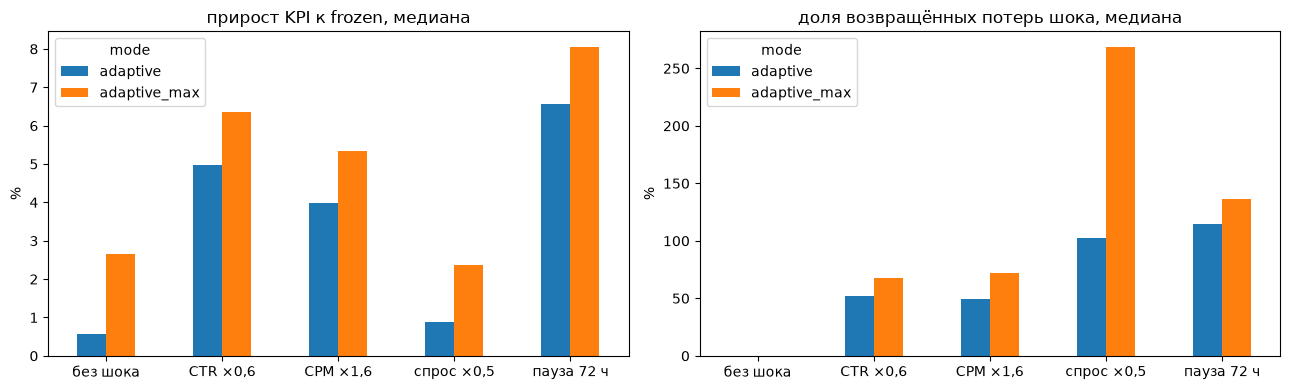

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (col, title) in zip(axes, [('uplift', 'прирост KPI к frozen, медиана'), ('recovered', 'доля возвращённых потерь шока, медиана')]):
    piv = m3.groupby(['шок', 'mode'], observed=True)[col].median().unstack('mode')[['adaptive', 'adaptive_max']] * 100
    piv.plot.bar(ax=ax, rot=0); ax.axhline(0, color='k', lw=0.6); ax.set_title(title); ax.set_ylabel('%'); ax.set_xlabel('')
fig.tight_layout(); fig.savefig(FIG / 'tm_modes_h3.png', dpi=120)

## 2. Режимы по шокам, холодный план (история 0)

Холодный план хуже калиброван, поэтому лайв-режиму есть что исправлять и без шока.

In [4]:
m0 = pairs[pairs.cell == 'modes-h0'].copy(); m0['шок'] = pd.Categorical(m0.scenario.map(SCEN_RU), [SCEN_RU[s] for s in SCEN])
table(m0, ['mode', 'шок'])

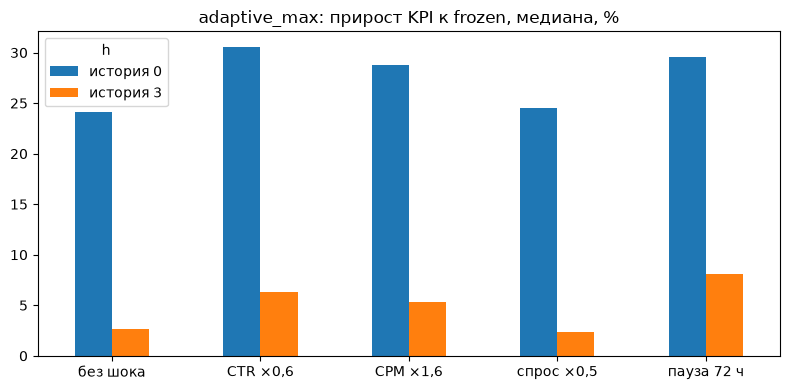

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
both = pd.concat([m3.assign(h='история 3'), m0.assign(h='история 0')])
piv = both[both['mode'] == 'adaptive_max'].groupby(['шок', 'h'], observed=True).uplift.median().unstack('h') * 100
piv.plot.bar(ax=ax, rot=0); ax.axhline(0, color='k', lw=0.6); ax.set_title('adaptive_max: прирост KPI к frozen, медиана, %'); ax.set_xlabel('')
fig.tight_layout(); fig.savefig(FIG / 'tm_cold_vs_warm.png', dpi=120)

## 3. Реакция на шок: траектория кэпа пострадавшего канала

Один мир, CTR ×0,6 с часа 252. Кэп канала в лайв-режиме со шоком относительно того же режима без шока.

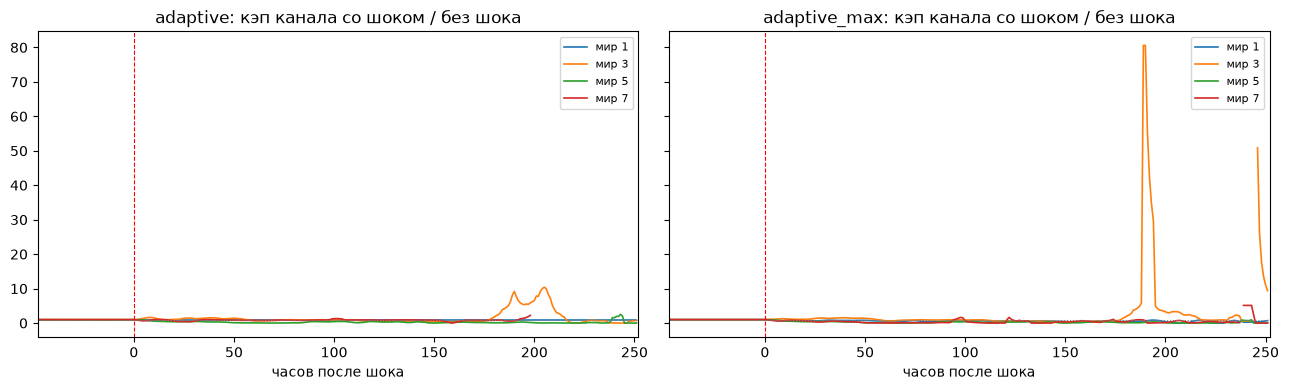

In [6]:
def caps(cell, run_id):
    return pd.read_csv(RESULTS / cell / 'trajectories' / f'{run_id}.csv').top_cap.values
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, mode in zip(axes, ['adaptive', 'adaptive_max']):
    for w in (1, 3, 5, 7):
        try:
            shock = caps('modes-h3', f'w{w}-c1-h3-ctr_drop-{mode}'); calm = caps('modes-h3', f'w{w}-c1-h3-none-{mode}')
        except FileNotFoundError:
            continue
        ratio = pd.Series(shock / np.where(calm > 0, calm, np.nan)).rolling(6, min_periods=1).mean()
        ax.plot(ratio.index - 252, ratio.values, lw=1.2, label=f'мир {w}')
    ax.axvline(0, color='r', ls='--', lw=0.8); ax.axhline(0.8, color='gray', ls=':', lw=0.8); ax.set_xlim(-48, 252)
    ax.set_title(f'{mode}: кэп канала со шоком / без шока'); ax.set_xlabel('часов после шока'); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG / 'tm_reaction.png', dpi=120)

## 4. Шумный мир: случайные события рынка включены, без сценарного шока

In [7]:
nz = pairs[pairs.cell.str.startswith('noisy')].copy(); nz['история'] = nz.history
table(nz, ['история', 'mode'])

## 5. Абляции лайв-цикла (adaptive_max, история 3)

Без свежих фактов — перепланирование не получает `current.recent_hours`, калибровка видит только накопленные итоги. Каденс — перепланирование раз в 6 и 24 часа вместо каждого часа.

In [8]:
ab = pairs[(pairs['mode'] == 'adaptive_max') & pairs.cell.isin(['modes-h3', 'ablate-no-recent-h3', 'cadence-6h-h3', 'cadence-24h-h3']) & pairs.scenario.isin(['none', 'ctr_drop'])].copy()
ab['вариант'] = ab.cell.map({'modes-h3': 'каждый час, со свежими фактами', 'ablate-no-recent-h3': 'каждый час, без свежих фактов', 'cadence-6h-h3': 'раз в 6 ч', 'cadence-24h-h3': 'раз в 24 ч'})
ab['шок'] = ab.scenario.map(SCEN_RU)
table(ab, ['вариант', 'шок'])

## 6. Момент шока (CTR ×0,6, adaptive_max, история 3)

In [9]:
tm = pairs[(pairs['mode'] == 'adaptive_max') & (pairs.scenario == 'ctr_drop') & pairs.cell.isin(['shock-early-h3', 'modes-h3', 'shock-late-h3'])].copy()
tm['момент'] = tm.cell.map({'shock-early-h3': 'час 120 (день 6)', 'modes-h3': 'час 252 (день 11)', 'shock-late-h3': 'час 400 (день 17)'})
table(tm, 'момент')

,пар,прирост p50,прирост p10,побед,возвращено p50,"реакция, ч p50",отреагировал,перераспределено p50,освоение p50,|dev KPI| p50
момент,,,,,,,,,,
час 120 (день 6),16,+8.3%,+2.7%,100%,+43%,8,100%,46%,100.0%,9.5%
час 252 (день 11),16,+6.4%,+2.7%,100%,+68%,7,100%,43%,100.0%,5.7%
час 400 (день 17),16,+3.6%,+1.4%,94%,+122%,6,100%,37%,100.0%,9.0%


## 7. Второй KPI: клики (история 3)

In [10]:
ck = pairs[pairs.cell == 'clicks-h3'].copy(); ck['шок'] = ck.scenario.map(SCEN_RU)
table(ck, ['mode', 'шок'])

,,пар,прирост p50,прирост p10,побед,возвращено p50,"реакция, ч p50",отреагировал,перераспределено p50,освоение p50,|dev KPI| p50
mode,шок,,,,,,,,,,


## 8. Цена лайв-режима по метрике кейса

Лайв-режим уходит от утверждённого плана. Отклонение факта от плана у лайв-прогона против frozen на той же паре.

In [11]:
dv = m3.assign(dev_live=m3.dev_kpi.abs(), dev_frozen=m3.dev_kpi_frozen.abs())
g = dv.groupby(['mode', 'шок'], observed=True)
pd.DataFrame({'|dev| frozen p50': g.dev_frozen.median(), '|dev| лайв p50': g.dev_live.median(), 'лайв в пороге 20 %': g.dev_live.apply(lambda s: (s <= 0.2).mean())}).style.format({'|dev| frozen p50': '{:.1%}', '|dev| лайв p50': '{:.1%}', 'лайв в пороге 20 %': '{:.0%}'})

## Выводы

1. **Лайв-исполнение даёт больше KPI, чем замороженный план, почти всегда.** На тёплом плане (история 3) `adaptive_max` выигрывает у frozen в 88 % пар без шока (+2,7 %) и в 96–100 % пар на шоках (+5…+8 %). `adaptive` осторожнее: +0,6 % без шока и +1…+7 % на шоках, потому что держит утверждённый микс, пока прогноз укладывается в план.
2. **Главная ценность трафик-менеджера — исправление плохого плана.** На холодном плане (только каталог) `adaptive_max` даёт +24…+31 % конверсий во всех 16 парах при любом шоке и +26 % в шумном мире. Это тот же разрыв, который в эксперименте A закрывала история: лайв-калибровка по фактам делает то же самое за первые дни кампании.
3. **Реакция на шок — 4–7 часов** для CTR, CPM и паузы у `adaptive_max` (у `adaptive` на тёплом плане 8–24 ч, и реагирует лишь в 62–81 % пар). На падение спроса реакция формально медленная (14–80 ч): канал сам перестаёт тратить, срезать кэп незачем, а неосвоенный бюджет уходит в другие каналы — поэтому возвращённая доля потерь там больше 100 %.
4. **Бюджет осваивается на 100 % во всех режимах**, перерасхода нет.
5. **Цена по метрике кейса.** На тёплом плане лайв-режимы отклоняются от утверждённого плана на 4–9 % (в пороге 20 %), причём в сторону перевыполнения. На холодном плане `adaptive_max` уходит от плана на ~30 %: план был неверен, факт лучше плана. Если метрику кейса считать буквально, холодный план плюс `adaptive_max` штрафуется за перевыполнение; лечится это не режимом, а историей (эксперимент A) либо пересогласованием плана после первых дней.
6. **Шумный мир** (случайные события рынка) не меняет картину: +2,8 % на тёплом плане, +25,6 % на холодном.
7. **Свежие факты — главный компонент лайв-цикла.** Без `current.recent_hours` (калибровка только по накопленным итогам) прирост без шока исчезает (−0,2 %, побед 44 %), на CTR-шоке падает с +6,4 % до +3,4 %, а реакция растягивается с 7 до 116 часов. Каденс перепланирования важен меньше: раз в 6 часов почти не хуже ежечасного (+5,8 % против +6,4 %, реакция 9 ч), раз в сутки уже теряет (+4,4 %, реакция 16 ч).
8. **Момент шока.** Чем раньше шок, тем больше прирост лайв-режима (+8,3 % на 6-й день, +6,4 % на 11-й, +3,6 % на 17-й): больше оставшегося бюджета, которым можно распорядиться. Реакция 6–8 ч не зависит от момента.
9. **Клики** — раздел 7; если он пуст, ячейка не успела досчитаться к дедлайну, её дозапускает та же команда из README (`tm_eval.py` пропускает готовые ячейки).
